In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from package.flows.online.flow import get_online_flow, Shared
from uuid import uuid4
from broflow import state

d:\broai-arai\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Loading model from: BAAI/bge-m3


Fetching 30 files: 100%|██████████| 30/30 [00:00<?, ?it/s]


In [38]:
def generate_experiments(
    embed_methods=['raw'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
            "us.meta.llama3-2-11b-instruct-v1:0",
        ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
):
    from itertools import product
    
    is_terms = ['skip', 'evidence', 'explanation']
    is_contexts = [True, False]
    
    experiments = []
    for (embed_method, chat_prompt, term_prompt, chat_model, term_model, 
         is_term, is_context) in product(
        embed_methods, chat_system_prompt_paths, term_detector_system_prompt_paths,
        chat_models, term_detector_models, is_terms, is_contexts
    ):
        base_config = {
            "embed_method": embed_method,
            "chat_system_prompt_path": chat_prompt,
            "term_detector_system_prompt_path": term_prompt,
            "chat_model": chat_model,
            "term_detector_model": term_model,
            "is_term": is_term,
            "is_context": is_context
        }
        
        if is_context:
            experiments.extend([
                {**base_config, "is_rerank": False},
                {**base_config, "is_rerank": True}
            ])
        else:
            experiments.append({**base_config, "is_rerank": False})
    
    return experiments


In [39]:
from dataclasses import dataclass, asdict

@dataclass
class ControlExperiment:
    chat_model:str
    chat_system_prompt_path:str
    term_detector_model:str
    term_detector_system_prompt_path:str
    embed_method:str
    is_term:str
    is_context:bool
    is_rerank:bool
    experiment_set:str

In [40]:
experiments = generate_experiments(
    embed_methods=['raw', 'combo'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
        "us.meta.llama3-2-1b-instruct-v1:0",
        "us.meta.llama3-2-11b-instruct-v1:0",
        "us.meta.llama4-maverick-17b-instruct-v1:0",
        "us.meta.llama4-scout-17b-instruct-v1:0",
        "meta.llama3-3-70b-instruct-v1:0",
        "us.meta.llama3-2-90b-instruct-v1:0",
    ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
)
len(experiments)

108

In [41]:
len(experiments)

108

In [42]:
import json

with open("./dataset/trainset.json", 'r', encoding='utf-8') as f:
    trainset = json.load(f)

In [43]:
for ts in trainset:
    ts['metadata']['source'] = ts['metadata']['source'].replace(":", "")

In [ ]:
def one_experiment(ts, con_exp:ControlExperiment):
    _id = str(uuid4())
    experiment_storage = "./evaluations/{file}.json".format(file=_id)
    shared = Shared(
        experiment_id=_id,
        experiment_set=con_exp.experiment_set,
        question=ts['question'],
        answer=ts['answer'],
        type=ts['type'],
        source=ts['metadata']['source'],
        chat_model=con_exp.chat_model,
        term_detector_model=con_exp.term_detector_model,
        chat_system_prompt_path=con_exp.chat_system_prompt_path,
        term_detector_system_prompt_path=con_exp.term_detector_system_prompt_path,
        experiment_storage=experiment_storage,
        embed_method=con_exp.embed_method,
        is_term=con_exp.is_term,
        is_context=con_exp.is_context,
        is_rerank=con_exp.is_rerank

    )

    flow = get_online_flow(experiment=shared.experiment_id)
    flow.run(shared)    

def main(trainset, experiments):
    for experiment in experiments:
        experiment.update({"experiment_set":str(uuid4())})
        con_exp = ControlExperiment(**experiment)
        for ts in trainset:
            one_experiment(ts, con_exp)

In [29]:
state.set('debug', False)
main(trainset[0:1], experiments[0:1])

Start bbc42273-a0ab-419f-84a1-538376eeb2a2


d:\broai-arai\backend\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


End bbc42273-a0ab-419f-84a1-538376eeb2a2


In [1]:
import json
import glob
import pandas as pd

def load_evaluations_to_dataframe(evaluations_dir="./experiments/sixth_evaluations"):
    data = []
    
    for file_path in glob.glob(f"{evaluations_dir}/*.json"):
        with open(file_path, 'r') as f:
            record = json.load(f)
        
        # Extract and flatten evaluation metrics
        if 'evaluation' in record:
            eval_data = record.pop('evaluation')
            for metric, values in eval_data.items():
                if isinstance(values, dict):
                    for sub_metric, value in values.items():
                        record[f"eval_{metric}_{sub_metric}"] = value
                else:
                    record[f"eval_{metric}"] = values
        
        data.append(record)
    
    df = pd.DataFrame(data)
    df.insert(0, "experiment", evaluations_dir.split("/")[-1])
    model_mapping = {
        'us.meta.llama4-maverick-17b-instruct-v1:0': 'Maverick-17B',
        'us.meta.llama3-2-11b-instruct-v1:0': 'Llama3.2-11B', 
        'us.meta.llama4-scout-17b-instruct-v1:0': 'Scout-17B'
    }
    df['chat_model_short'] = df['chat_model'].map(model_mapping)    
    df['config'] = df['chat_model_short'].astype(str) + '_' + df['is_term'].astype(str) + '_' + df['is_context'].astype(str) + '_' + df['is_rerank'].astype(str)
    return df


In [2]:
experiments = [
    './experiments/seventh_evaluations', 
    # './experiments/sixth_evaluations'
]
df = pd.concat([load_evaluations_to_dataframe(exp) for exp in experiments], axis=0, ignore_index=True)
df.shape

(1188, 42)

In [3]:
df.to_csv('completed_experiments.csv', index=False)

In [204]:
df.head()

,experiment,question,answer,type,source,experiment_id,experiment_set,experiment_storage,document_id,document_source,...,eval_rougeL_fmeasure,eval_rougeLsum_precision,eval_rougeLsum_recall,eval_rougeLsum_fmeasure,eval_hotpot_em,eval_hotpot_f1,eval_hotpot_precision,eval_hotpot_recall,chat_model_short,config
0,fifth_evaluations,What is LOGICOL?,LOGICOL is a logically-informed contrastive le...,explanation,LOGICOL Logically-Informed Contrastive Learnin...,005ba099-bc7d-44b1-9bf6-059c9190d84d,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,./experiments/fifth_evaluations/005ba099-bc7d-...,df47df55-be76-403e-b7c8-fc57d0e3935c,LOGICOL Logically-Informed Contrastive Learnin...,...,0.272727,0.164384,0.800000,0.272727,0.0,0.311688,0.187500,0.923077,Maverick-17B,Maverick-17B_both_True_False
1,fifth_evaluations,What does STORM stand for?,Synthesis of Topic Outlines through Retrieval ...,acronym,Assisting in Writing Wikipedia-like Articles F...,00963422-0a81-453e-bf01-a8ccdc701488,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,./experiments/fifth_evaluations/00963422-0a81-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.880000,0.785714,1.000000,0.880000,0.0,0.869565,0.769231,1.000000,Maverick-17B,Maverick-17B_skip_True_True
2,fifth_evaluations,What is POQD?,POQD is a novel query decomposition framework ...,explanation,POQD Performance-Oriented Query Decomposer for...,00a119c0-9cf3-40e1-8da9-8dfa5d15ff48,60a34ecb-a509-4f0d-bf6f-72f8a6d4e15a,./experiments/fifth_evaluations/00a119c0-9cf3-...,c15d3840-4701-4cc8-9842-2debdd453381,POQD Performance-Oriented Query Decomposer for...,...,0.237624,0.144578,0.666667,0.237624,0.0,0.298851,0.183099,0.812500,Llama3.2-11B,Llama3.2-11B_skip_True_False
3,fifth_evaluations,What is MASKSEARCH?,MASKSEARCH is a universal pre-training framewo...,explanation,MASKSEARCH A Universal Pre-Training Framework ...,00ef5b60-ec89-4217-87b5-fd2148e5a55c,1075ce17-013f-46b6-a315-1579f101f786,./experiments/fifth_evaluations/00ef5b60-ec89-...,9b8418e9-6f5f-4116-b3ed-7eef0b58c34c,MASKSEARCH A Universal Pre-Training Framework ...,...,0.389610,0.267857,0.714286,0.389610,0.0,0.393939,0.265306,0.764706,Maverick-17B,Maverick-17B_explanation_False_False
4,fifth_evaluations,What is STORM?,STORM is a writing system for the Synthesis of...,explanation,Assisting in Writing Wikipedia-like Articles F...,00f2ea66-01ba-45e6-bbf1-b370669de045,b3002635-bda5-4f61-8f85-533be2845275,./experiments/fifth_evaluations/00f2ea66-01ba-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.095890,0.054688,0.388889,0.095890,0.0,0.075758,0.042735,0.333333,Llama3.2-11B,Llama3.2-11B_skip_False_False


In [214]:
def average_evaluation_metrics_by_experiment_set(df, grp_col=['experiment_set']):
    eval_columns = [col for col in df.columns if col.startswith('eval_')]
    numeric_eval_columns = df[eval_columns].select_dtypes(include=['number']).columns
    return df.groupby(grp_col)[numeric_eval_columns].mean().reset_index()

grp_col = [
    'experiment',
    'experiment_set',
    'config',
    # 'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)

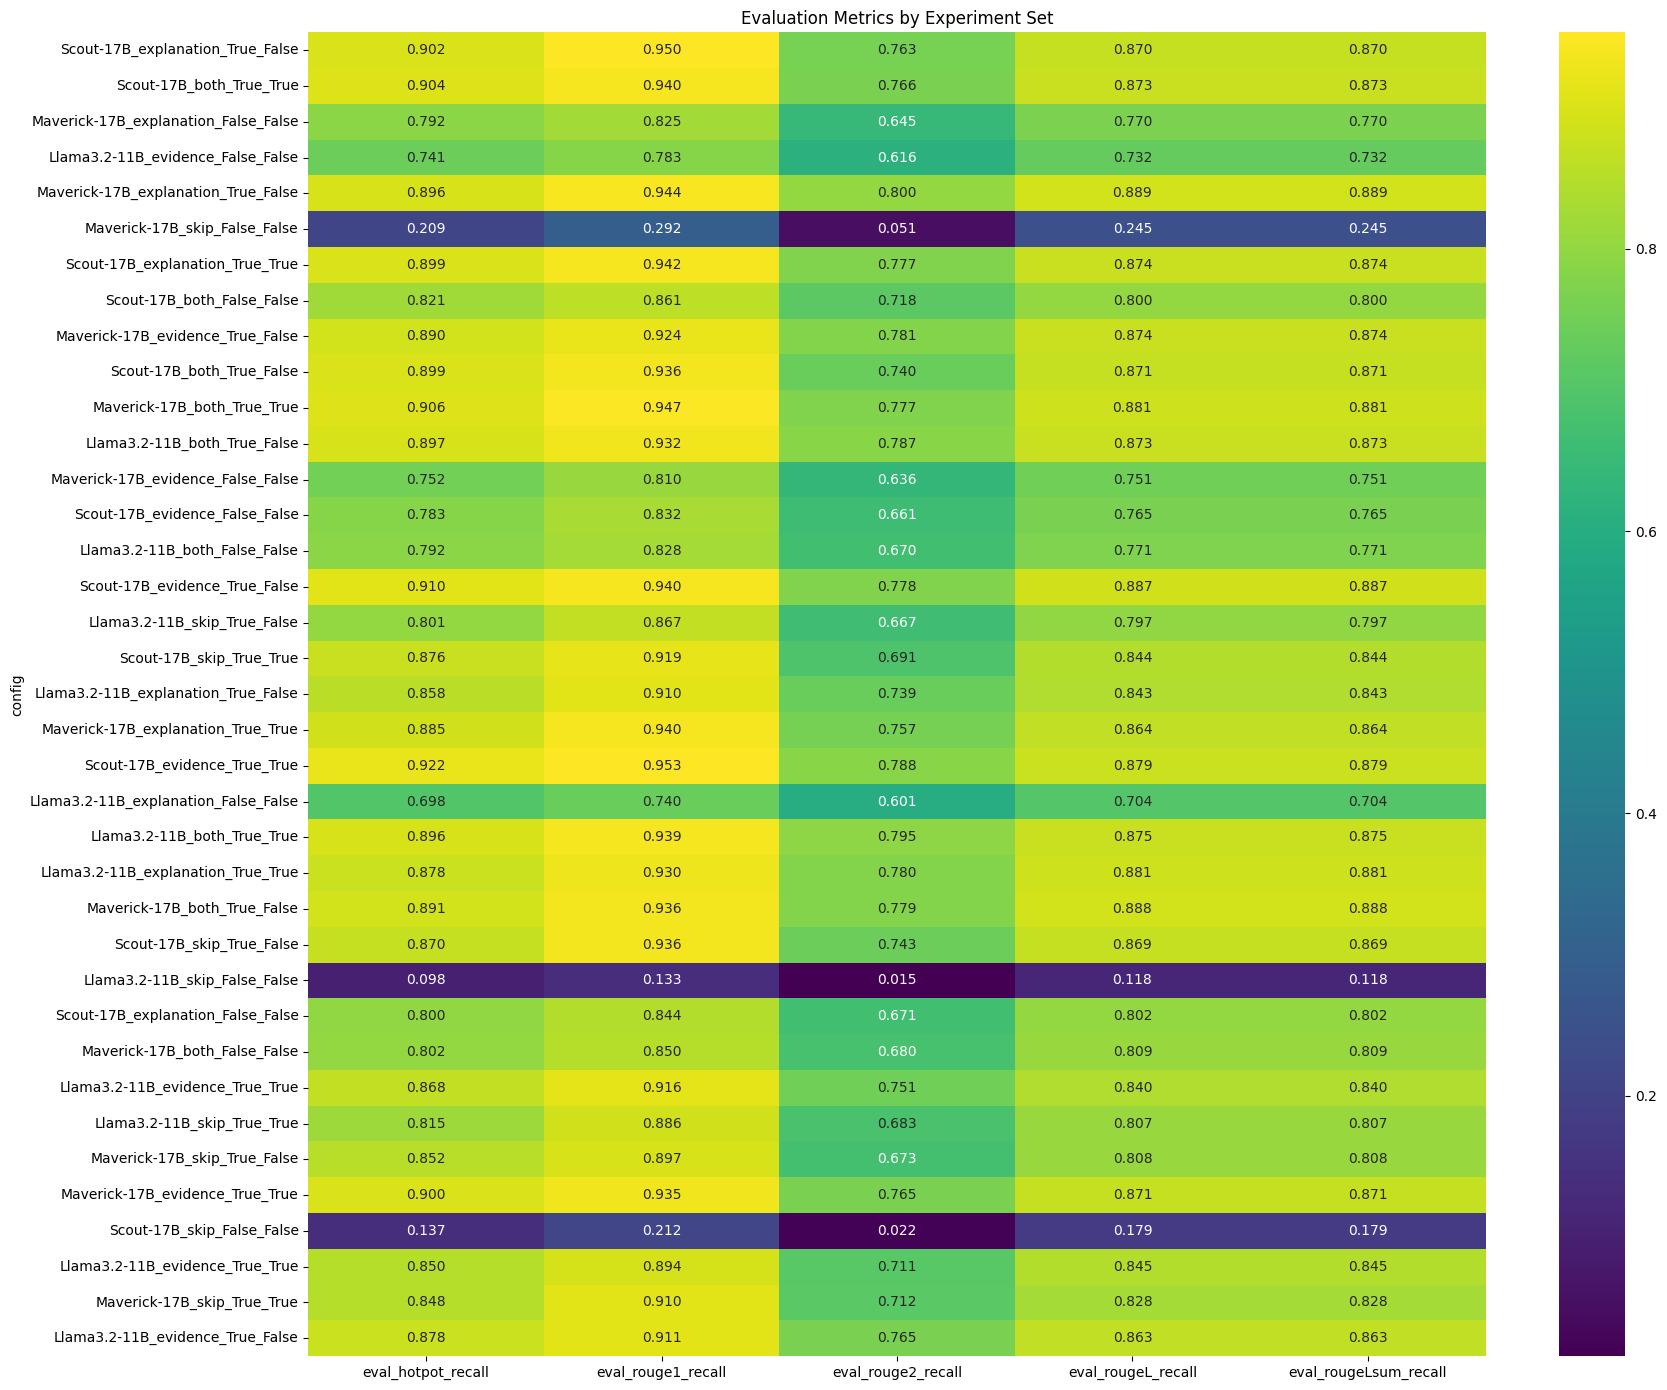

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_metrics(grp, set_index=['experiment_set'], suffixes=['_f1','_fmeasure', '_recall', '_precision']):
    eval_cols = [col for col in grp.columns if col.startswith('eval_') 
                 and any(col.endswith(suffix) for suffix in suffixes)]
    eval_cols = sorted(eval_cols)
    pivot_data = grp.set_index(set_index)[eval_cols]
    
    plt.figure(figsize=(18, 14))
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis')
    plt.title('Evaluation Metrics by Experiment Set')
    plt.tight_layout()
    plt.show()



# Quick ranking
def rank_experiments(grp, metric='eval_rouge1_fmeasure'):
    return grp.nlargest(10, metric)[['experiment_set', metric]]

# Usage examples:
visualize_metrics(grp, 
    suffixes=[
    # '_f1', 
    # '_fmeasure',
    '_recall',
    # '_precision',
    ],
    set_index=[
        # 'experiment',
        # 'is_term',
        # 'is_context',
        # 'is_rerank',
        # 'chat_model',
        'config',
        # 'type',
    ]
)

In [35]:
grp.columns

Index(['experiment', 'experiment_set', 'type', 'chat_model', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [36]:
target_cols = ['experiment', 'experiment_set', 'chat_model', 'is_term', 'is_context', 'is_rerank', 'type']

In [43]:
cols = list(grp.columns[grp.columns.str.endswith("_recall")])
cols

['eval_rouge1_recall',
 'eval_rouge2_recall',
 'eval_rougeL_recall',
 'eval_rougeLsum_recall',
 'eval_hotpot_recall']

In [46]:
metric = 'rougeL'
_metric_typ = 'recall'

grp_col = [
    'experiment',
    'experiment_set',
    # 'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)
mask = grp['is_context'] == True
mask &= grp['is_rerank'] == True
col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols[:-1]+cols].nlargest(30, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
23,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,0.929672,0.780008,0.881135,0.881135,0.878401
10,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,0.947256,0.777186,0.880826,0.880826,0.905522
20,fifth_evaluations,8190377d-8362-4467-871e-3242dee4fb1b,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,True,0.953454,0.787607,0.878791,0.878791,0.922414
22,fifth_evaluations,8ea35458-8365-4ad1-99d6-e6c5c12f4f18,us.meta.llama3-2-11b-instruct-v1:0,both,True,True,0.938866,0.794932,0.874747,0.874747,0.896389
6,fifth_evaluations,264a77e8-3ee7-443e-9124-114762f75f90,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,0.941511,0.777005,0.874196,0.874196,0.899451
1,fifth_evaluations,036536d6-420d-4238-9183-e0c59136ab17,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,0.940394,0.765625,0.873496,0.873496,0.904051
32,fifth_evaluations,d00021f9-5e24-428b-b4fd-90adbe088d5b,us.meta.llama4-maverick-17b-instruct-v1:0,evidence,True,True,0.935131,0.765365,0.870972,0.870972,0.899972
19,fifth_evaluations,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,0.940185,0.756675,0.863688,0.863688,0.884907
34,fifth_evaluations,e91524b0-2c04-4612-8c72-ac979f3cec88,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,True,0.893602,0.711159,0.845023,0.845023,0.850074
17,fifth_evaluations,61f91994-a6f1-4a59-bf97-d8b39b61806d,us.meta.llama4-scout-17b-instruct-v1:0,skip,True,True,0.919395,0.690552,0.844374,0.844374,0.875817


In [47]:
new = 0.808928
old = 0.854191
((new-old)/old)

-0.052989319718891974

In [48]:
grp_col = [
    'experiment',
    'experiment_set',
    'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)

mask = grp['type'] == 'acronym'
# col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols+cols].nlargest(20, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,type,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
0,fifth_evaluations,01b02d4e-3233-4532-a624-dc3d5b1fd9fc,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
2,fifth_evaluations,036536d6-420d-4238-9183-e0c59136ab17,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
4,fifth_evaluations,1075ce17-013f-46b6-a315-1579f101f786,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,False,False,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
8,fifth_evaluations,16207ad6-730a-4c85-9401-bbd2bf90e8ec,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
12,fifth_evaluations,264a77e8-3ee7-443e-9124-114762f75f90,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
18,fifth_evaluations,37f53863-635c-4ce8-83d0-8de84cdcd94d,us.meta.llama4-scout-17b-instruct-v1:0,both,True,False,acronym,1.000000,1.000000,1.000000,1.000000,1.000000
20,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
36,fifth_evaluations,74763a11-2f80-4718-bf22-c1b4149ab9b3,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,False,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
38,fifth_evaluations,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697
46,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,acronym,1.000000,1.000000,1.000000,1.000000,0.969697


In [49]:
new = 1
old = 0.977273
((new-old)/old)

0.023255528393806086

In [50]:
mask = grp['type'] != 'acronym'
# col = f'eval_{metric}_{_metric_typ}'.format(metric=metric, _metric_typ=_metric_typ)
grp.loc[mask, target_cols+cols].nlargest(20, col)

,experiment,experiment_set,chat_model,is_term,is_context,is_rerank,type,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_rougeLsum_recall,eval_hotpot_recall
49,fifth_evaluations,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,False,explanation,0.915408,0.683970,0.844098,0.844098,0.862729
31,fifth_evaluations,567cf946-2c5a-48bc-b28e-f5d0f870d3b9,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,False,explanation,0.921349,0.681413,0.842308,0.842308,0.877077
9,fifth_evaluations,16207ad6-730a-4c85-9401-bbd2bf90e8ec,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,explanation,0.915396,0.700190,0.834231,0.834231,0.858456
69,fifth_evaluations,e91524b0-2c04-4612-8c72-ac979f3cec88,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,True,explanation,0.896014,0.681545,0.831243,0.831243,0.841765
41,fifth_evaluations,8190377d-8362-4467-871e-3242dee4fb1b,us.meta.llama4-scout-17b-instruct-v1:0,evidence,True,True,explanation,0.941544,0.696561,0.829550,0.829550,0.894984
73,fifth_evaluations,fcba4af2-bb7c-4c44-a769-8a9db0742fa9,us.meta.llama3-2-11b-instruct-v1:0,evidence,True,False,explanation,0.899274,0.699495,0.827207,0.827207,0.850776
45,fifth_evaluations,8ea35458-8365-4ad1-99d6-e6c5c12f4f18,us.meta.llama3-2-11b-instruct-v1:0,both,True,True,explanation,0.919663,0.707550,0.823484,0.823484,0.855947
47,fifth_evaluations,94b81a1c-782d-42c0-9e89-ebe418683680,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,explanation,0.894508,0.670012,0.821703,0.821703,0.832754
17,fifth_evaluations,3316e6dc-dc58-4690-b55e-5e63747c49ad,us.meta.llama4-maverick-17b-instruct-v1:0,evidence,True,False,explanation,0.896697,0.686509,0.821664,0.821664,0.846645
21,fifth_evaluations,411900cc-455d-4f0a-a05b-39e2f448cab2,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,explanation,0.920885,0.665778,0.821240,0.821240,0.873434


In [42]:
new = 0.844098
old = 0.831243
(new-old)/old

0.015464791883961803

In [64]:
df.shape, grp.shape

((1188, 39), (74, 22))

In [52]:
grp.columns

Index(['experiment', 'experiment_set', 'type', 'chat_model', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [60]:
metrics = [
    "eval_rougeL_recall"
]
aggs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in metrics}
mask = df['type'] == 'acronym'
df.loc[mask,:].groupby(['chat_model', 'is_term','is_context', 'is_rerank']).agg(**aggs).reset_index().sort_values('eval_rougeL_recall', ascending=False)

,chat_model,is_term,is_context,is_rerank,eval_rougeL_recall
14,us.meta.llama4-maverick-17b-instruct-v1:0,both,True,True,1.000000
19,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,False,1.000000
8,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,True,1.000000
7,us.meta.llama3-2-11b-instruct-v1:0,explanation,True,False,1.000000
31,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,False,1.000000
30,us.meta.llama4-scout-17b-instruct-v1:0,explanation,False,False,1.000000
32,us.meta.llama4-scout-17b-instruct-v1:0,explanation,True,True,1.000000
20,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,True,True,1.000000
18,us.meta.llama4-maverick-17b-instruct-v1:0,explanation,False,False,1.000000
26,us.meta.llama4-scout-17b-instruct-v1:0,both,True,True,1.000000


In [61]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [68]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

In [71]:
target_cols = [
    'chat_model', 'answer', 'predict', 'is_term', 'is_context', 'is_rerank', 
        # 'eval_rouge1_precision',
       'eval_rouge1_recall', 
    #    'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 
    #    'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 
    #    'eval_rougeL_fmeasure',
    #    'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
    #    'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
    #    'eval_hotpot_precision', 
       'eval_hotpot_recall'    
]
mask = True
# mask &= df['experiment_set']=='8190377d-8362-4467-871e-3242dee4fb1b'
mask &= df['question'] == 'What does DiscoVLA stand for?'
df.loc[mask, target_cols]

,chat_model,answer,predict,is_term,is_context,is_rerank,eval_rouge1_recall,eval_rouge2_recall,eval_rougeL_recall,eval_hotpot_recall
19,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,evidence,True,True,1.000000,1.0,1.000000,1.000000
21,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,True,False,1.000000,1.0,1.000000,1.000000
43,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,False,1.000000,1.0,1.000000,1.000000
87,us.meta.llama3-2-11b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",Based on the provided TERMS and CONTEXTS infor...,evidence,True,False,1.000000,1.0,1.000000,1.000000
102,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,True,1.000000,1.0,1.000000,1.000000
147,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,evidence,True,False,1.000000,1.0,1.000000,1.000000
194,us.meta.llama4-scout-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,both,True,False,1.000000,1.0,1.000000,1.000000
247,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,True,True,1.000000,1.0,1.000000,1.000000
278,us.meta.llama3-2-11b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...","Based on the provided CONTEXTS, DiscoVLA stand...",skip,True,True,0.285714,0.0,0.285714,0.285714
354,us.meta.llama4-maverick-17b-instruct-v1:0,"Discrepancy Reduction in Vision, Language, and...",DiscoVLA stands for Discrepancy Reduction in V...,explanation,False,False,1.000000,1.0,1.000000,1.000000


In [3]:
import seaborn as sns

In [4]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall'],
      dtype='object')

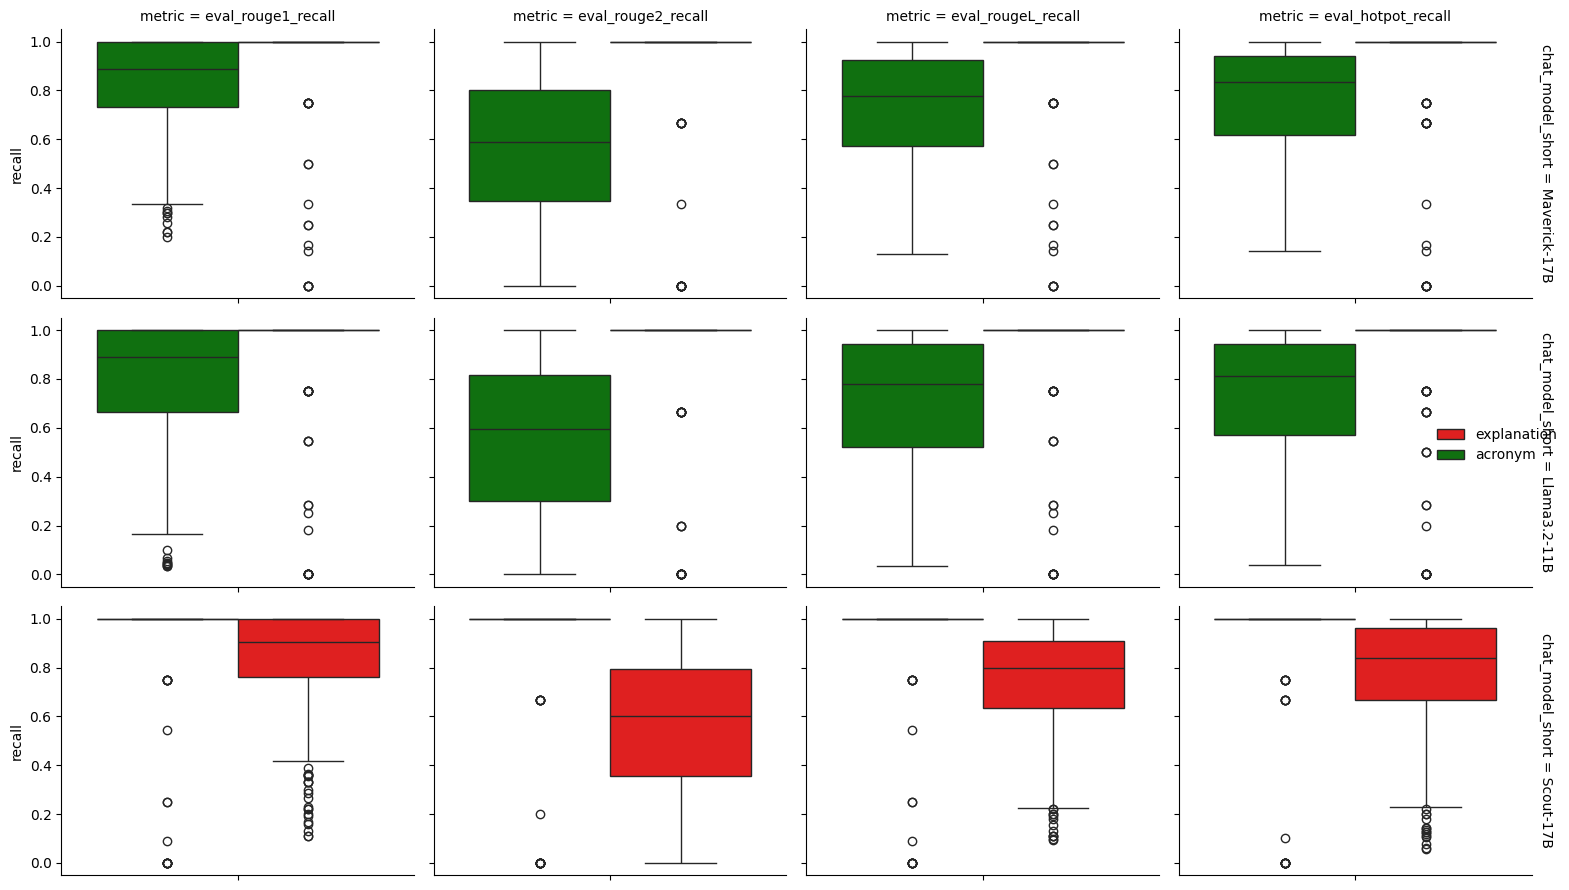

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create shorter model names
model_mapping = {
    'us.meta.llama4-maverick-17b-instruct-v1:0': 'Maverick-17B',
    'us.meta.llama3-2-11b-instruct-v1:0': 'Llama3.2-11B', 
    'us.meta.llama4-scout-17b-instruct-v1:0': 'Scout-17B'
}
df['chat_model_short'] = df['chat_model'].map(model_mapping)

# Melt and plot
metrics = ['eval_rouge1_recall', 'eval_rouge2_recall', 'eval_rougeL_recall', 'eval_hotpot_recall']
df_melted = df.melt(
    id_vars=['chat_model_short', 'type'], 
    value_vars=metrics,
    var_name='metric', 
    value_name='recall'
)

g = sns.FacetGrid(df_melted, row='chat_model_short', col='metric', margin_titles=True, aspect=1.2)
g.map_dataframe(sns.boxplot, y='recall', hue='type', palette=['green', 'red'])
g.add_legend()
plt.tight_layout()
plt.show()




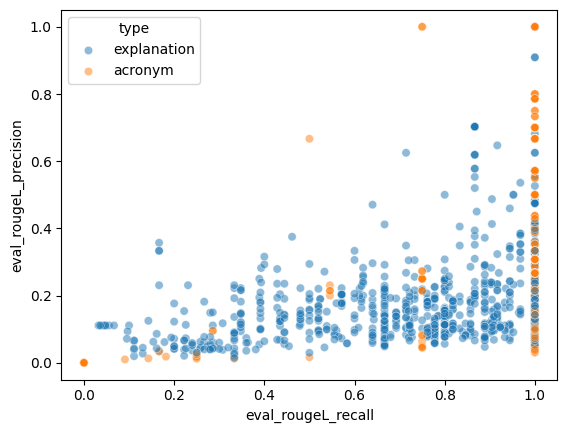

In [16]:
sns.scatterplot(df, x='eval_rougeL_recall', y='eval_rougeL_precision', hue='type', alpha=0.5);

In [20]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall', 'chat_model_short'],
      dtype='object')

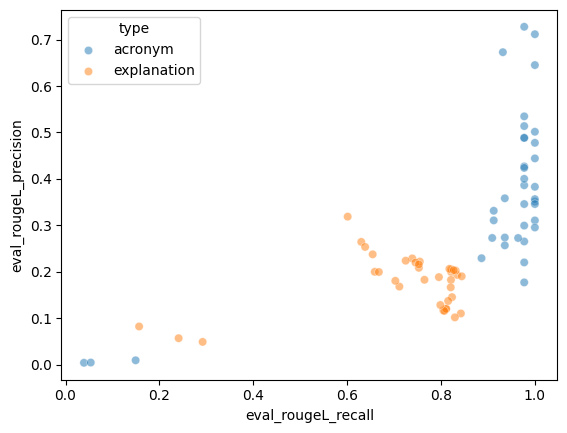

In [26]:
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['experiment_set', 'type']).agg(**aggfuncs).reset_index()
sns.scatterplot(grp, x='eval_rougeL_recall', y='eval_rougeL_precision', hue='type', alpha=0.5);

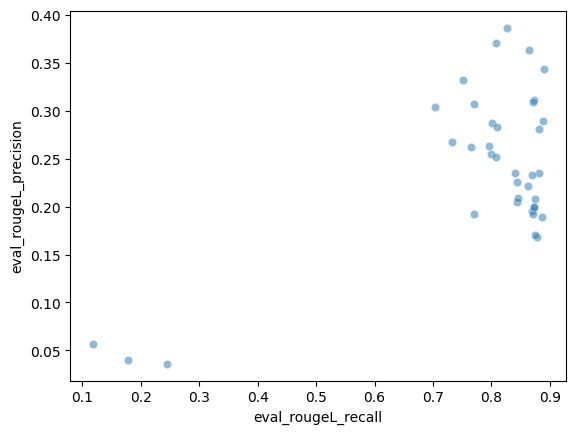

In [27]:
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['experiment_set']).agg(**aggfuncs).reset_index()
sns.scatterplot(grp, x='eval_rougeL_recall', y='eval_rougeL_precision', alpha=0.5);

In [30]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall', 'chat_model_short'],
      dtype='object')

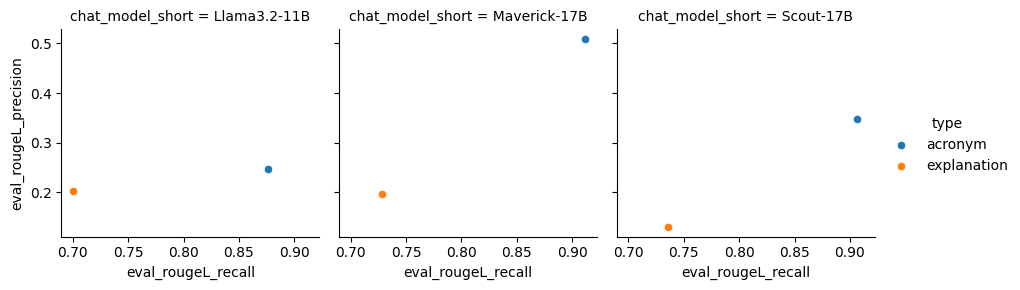

In [32]:
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['chat_model_short', 'type']).agg(**aggfuncs).reset_index()
# sns.scatterplot(grp, x='eval_rougeL_recall', y='eval_rougeL_precision', hue='type', alpha=0.5)
g = sns.FacetGrid(grp, col="chat_model_short", hue="type")
g.map_dataframe(sns.scatterplot, x="eval_rougeL_recall", y="eval_rougeL_precision")
g.add_legend();

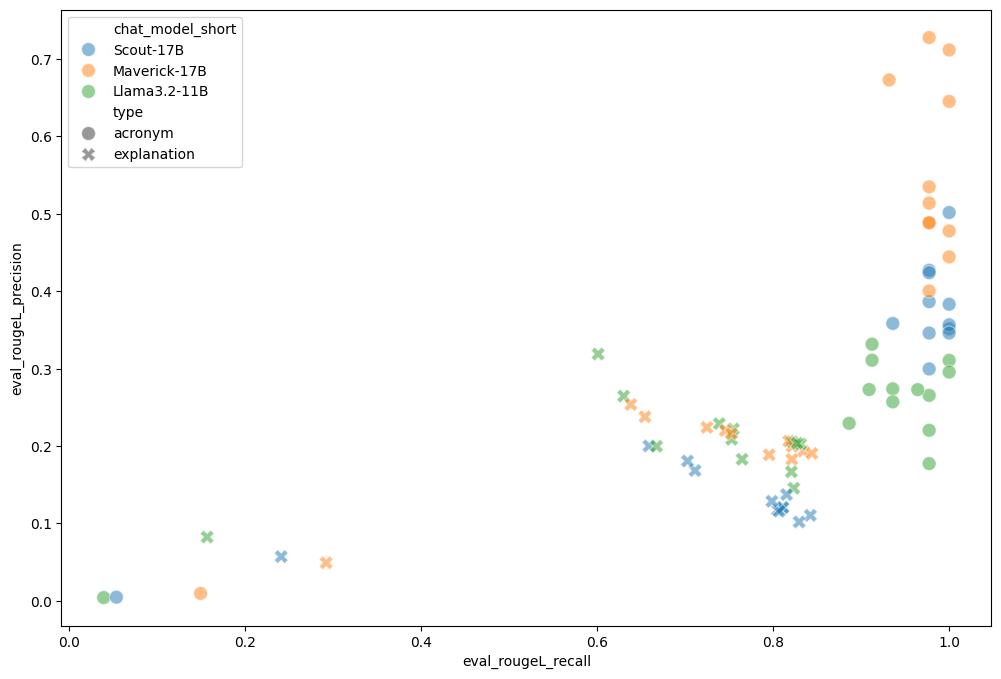

In [37]:
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['experiment_set', 'chat_model_short', 'type']).agg(**aggfuncs).reset_index()
plt.figure(figsize=(12, 8))
sns.scatterplot(grp, x='eval_rougeL_recall', y='eval_rougeL_precision', style='type', hue='chat_model_short', s=100,alpha=0.5);

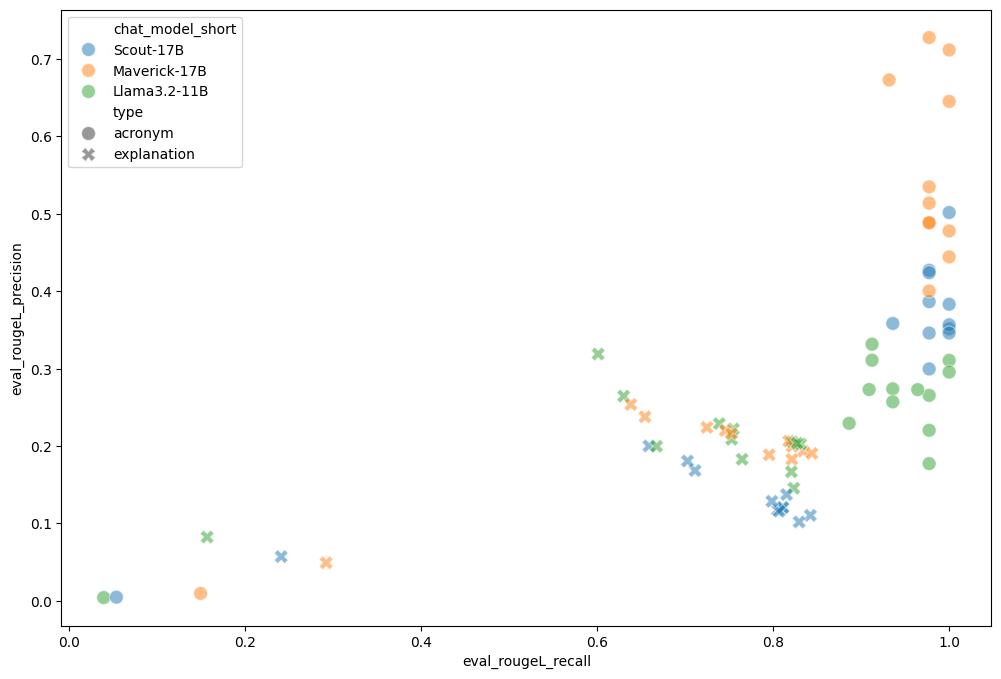

In [38]:
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['experiment_set', 'chat_model_short', 'type', 'is_term', 'is_context', 'is_rerank']).agg(**aggfuncs).reset_index()
plt.figure(figsize=(12, 8))
sns.scatterplot(grp, x='eval_rougeL_recall', y='eval_rougeL_precision', style='type', hue='chat_model_short', s=100,alpha=0.5);

<Figure size 1200x800 with 0 Axes>

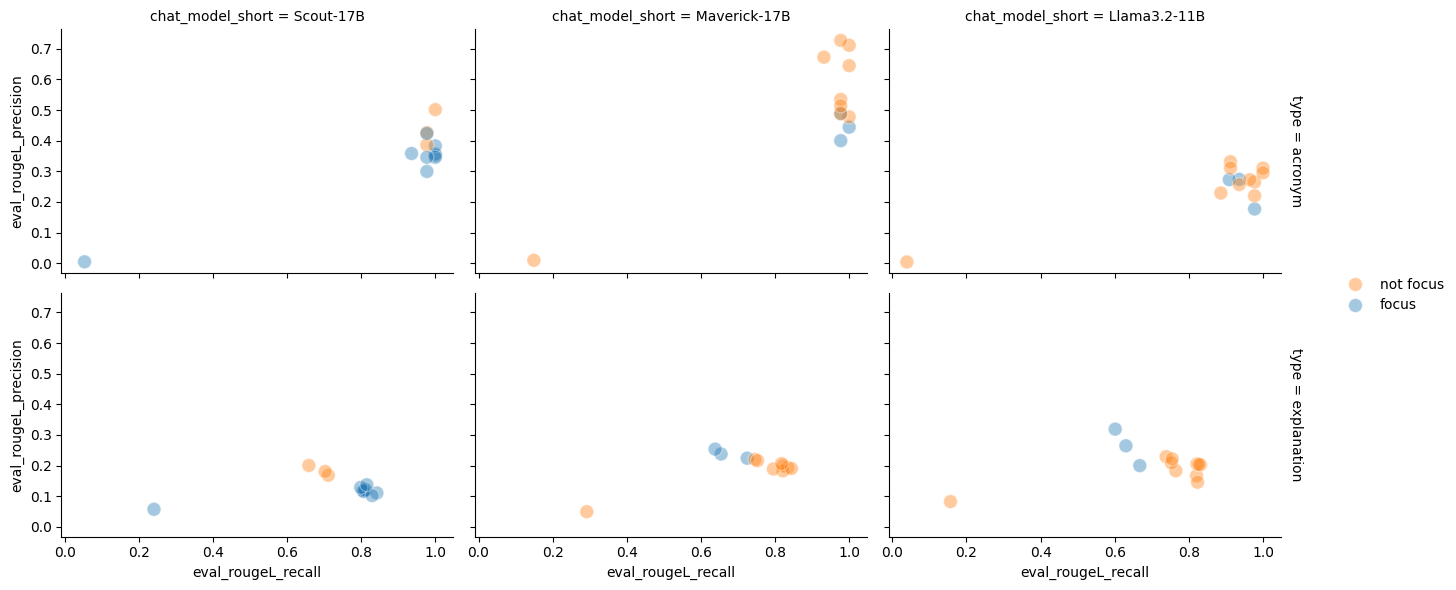

In [50]:
import numpy as np
aggfuncs = {str(met):pd.NamedAgg(column=met, aggfunc='mean') for met in ["eval_rougeL_recall", "eval_rougeL_precision"]}
grp = df.groupby(['experiment_set', 'chat_model_short', 'type', 'is_term', 'is_context', 'is_rerank']).agg(**aggfuncs).reset_index()
grp['focus'] = np.where(
    (grp['is_term']!='skip') & (grp['is_context']==False) & (grp['is_rerank']==False),
    'focus',
    'not focus'
)
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(grp, col="chat_model_short", row='type',margin_titles=True, aspect=1.5)
g.map_dataframe(sns.scatterplot, x="eval_rougeL_recall", y="eval_rougeL_precision", 
                hue='focus', 
                # style='type', 
                s=100, alpha=0.4)
g.add_legend();

In [52]:
grp.loc[grp['focus']=='focus', :].sort_values(by=['eval_rougeL_recall', 'eval_rougeL_precision'], ascending=False)

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus
54,ba8388fc-c770-4f5c-acc6-9549114d7d74,Scout-17B,acronym,explanation,False,False,1.000000,0.501574,focus
4,1075ce17-013f-46b6-a315-1579f101f786,Maverick-17B,acronym,explanation,False,False,1.000000,0.444256,focus
24,4b69fdab-471a-4abf-9d98-743a3cb38554,Maverick-17B,acronym,evidence,False,False,0.977273,0.488407,focus
14,29fea9bd-1c0f-4c11-962b-8e94d58599f6,Scout-17B,acronym,both,False,False,0.977273,0.427015,focus
56,bcb4ec10-e560-4dd9-a193-bf083b5fd918,Maverick-17B,acronym,both,False,False,0.977273,0.400242,focus
26,4cde48b2-779e-477d-b5d0-c1d5f4624ac3,Scout-17B,acronym,evidence,False,False,0.977273,0.386427,focus
28,543da329-6a3a-4065-9c2e-89c09676f5e2,Llama3.2-11B,acronym,both,False,False,0.977273,0.177274,focus
6,10c33865-8a09-45ce-8d5f-f4b212fb6dd6,Llama3.2-11B,acronym,evidence,False,False,0.935950,0.273896,focus
42,83728a4d-8e7e-47bc-9cbc-b403c6784467,Llama3.2-11B,acronym,explanation,False,False,0.909091,0.272991,focus
57,bcb4ec10-e560-4dd9-a193-bf083b5fd918,Maverick-17B,explanation,both,False,False,0.724756,0.224035,focus


In [57]:
# grp.loc[:, ['is_term', 'is_context', 'is_rerank']].drop_duplicates()
grp['config'] = grp['is_term'].astype(str) + '_' + grp['is_context'].astype(str) + '_' + grp['is_rerank'].astype(str)

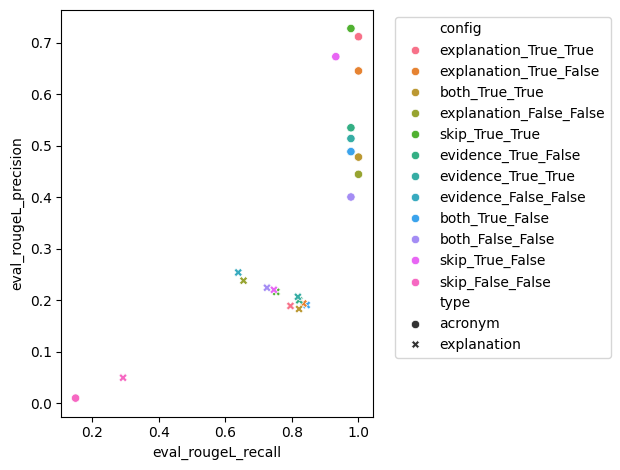

In [59]:
sns.scatterplot(
    grp.loc[grp['chat_model_short']=='Maverick-17B', :].sort_values(by=['eval_rougeL_recall', 'eval_rougeL_precision'], ascending=False),
    x='eval_rougeL_recall', y='eval_rougeL_precision', hue='config', style='type'
);

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

<Figure size 1200x800 with 0 Axes>

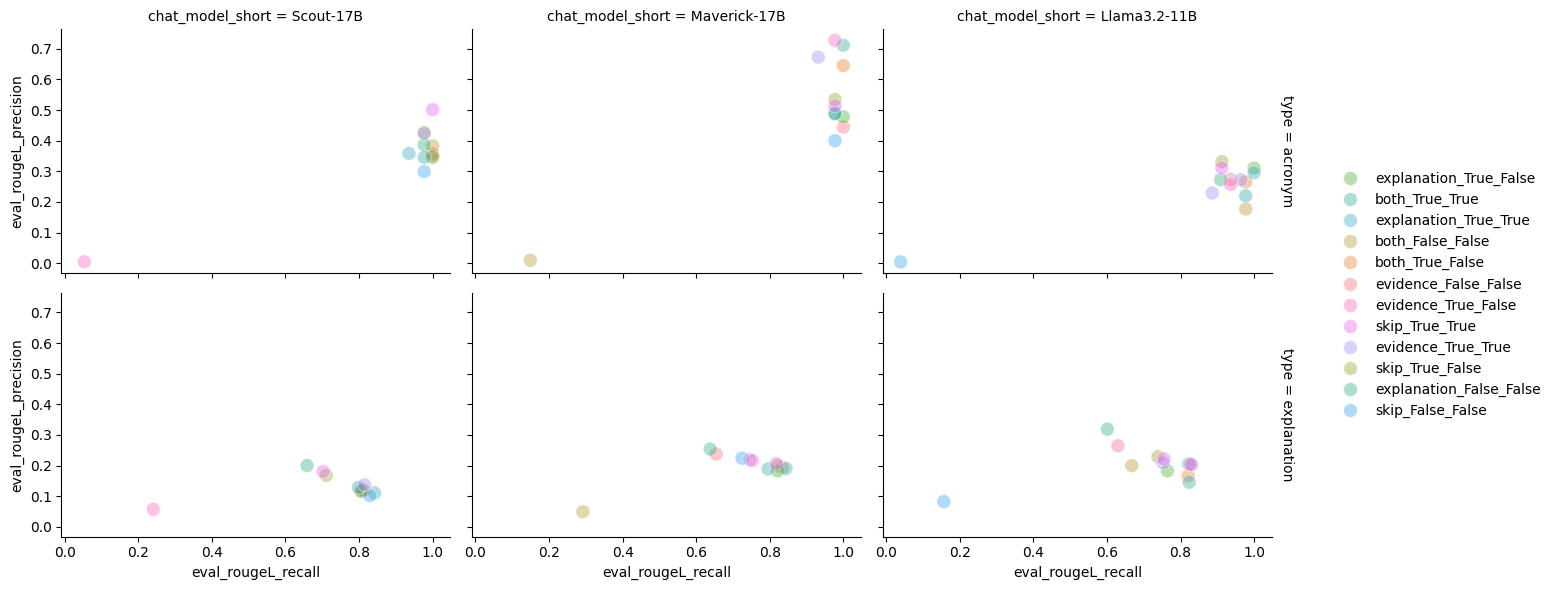

In [60]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(grp, col="chat_model_short", row='type',margin_titles=True, aspect=1.5)
g.map_dataframe(sns.scatterplot, x="eval_rougeL_recall", y="eval_rougeL_precision", 
                hue='config', 
                # style='type', 
                s=100, alpha=0.4)
g.add_legend();

In [63]:
import altair as alt

# Create selection for config
click = alt.selection_point(fields=['config'])

alt.Chart(grp).mark_circle(
    size=100,
    opacity=0.4
).add_params(
    click
).encode(
    x='eval_rougeL_recall',
    y='eval_rougeL_precision',
    color=alt.condition(click, 'config:N', alt.value('lightgray')),
    facet=alt.Facet('chat_model_short:N', columns=3),
    row='type:N'
).resolve_scale(
    color='independent'
).properties(
    width=800,
    height=400
)


alt.Chart(...)

In [74]:
import altair as alt

# Create selection for config
click = alt.selection_point(fields=['config'], bind='legend')

alt.Chart(grp).mark_circle(
    size=200,
    opacity=0.7
).add_params(
    click
).encode(
    x='eval_rougeL_recall',
    y='eval_rougeL_precision',
    color=alt.condition(click, 'config:N', alt.value('lightgray')),
    column=alt.Column('chat_model_short:N', header=alt.Header(titleOrient="bottom")),
    row='type:N'
).resolve_scale(
    color='independent'
).properties(
    width=300,
    height=300
)


alt.Chart(...)

In [76]:
mask = True
mask &= grp['config']=='skip_False_False'
grp.loc[mask,:]

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus,config
10,1bd47c47-a24c-4eec-b353-73a47ca3101b,Maverick-17B,acronym,skip,False,False,0.149351,0.009628,not focus,skip_False_False
11,1bd47c47-a24c-4eec-b353-73a47ca3101b,Maverick-17B,explanation,skip,False,False,0.292095,0.049223,not focus,skip_False_False
52,b3002635-bda5-4f61-8f85-533be2845275,Llama3.2-11B,acronym,skip,False,False,0.039256,0.004265,not focus,skip_False_False
53,b3002635-bda5-4f61-8f85-533be2845275,Llama3.2-11B,explanation,skip,False,False,0.156766,0.082419,not focus,skip_False_False
66,d07e0d6e-0eda-427c-bcb4-9d69df3775ab,Scout-17B,acronym,skip,False,False,0.053719,0.004777,not focus,skip_False_False
67,d07e0d6e-0eda-427c-bcb4-9d69df3775ab,Scout-17B,explanation,skip,False,False,0.240956,0.057177,not focus,skip_False_False


In [77]:
mask = True
mask &= grp['config']=='both_False_False'
grp.loc[mask,:]

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus,config
14,29fea9bd-1c0f-4c11-962b-8e94d58599f6,Scout-17B,acronym,both,False,False,0.977273,0.427015,focus,both_False_False
15,29fea9bd-1c0f-4c11-962b-8e94d58599f6,Scout-17B,explanation,both,False,False,0.711256,0.168339,focus,both_False_False
28,543da329-6a3a-4065-9c2e-89c09676f5e2,Llama3.2-11B,acronym,both,False,False,0.977273,0.177274,focus,both_False_False
29,543da329-6a3a-4065-9c2e-89c09676f5e2,Llama3.2-11B,explanation,both,False,False,0.667538,0.199698,focus,both_False_False
56,bcb4ec10-e560-4dd9-a193-bf083b5fd918,Maverick-17B,acronym,both,False,False,0.977273,0.400242,focus,both_False_False
57,bcb4ec10-e560-4dd9-a193-bf083b5fd918,Maverick-17B,explanation,both,False,False,0.724756,0.224035,focus,both_False_False


In [78]:
mask = True
mask &= grp['config']=='evidence_False_False'
grp.loc[mask,:]

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus,config
6,10c33865-8a09-45ce-8d5f-f4b212fb6dd6,Llama3.2-11B,acronym,evidence,False,False,0.935950,0.273896,focus,evidence_False_False
7,10c33865-8a09-45ce-8d5f-f4b212fb6dd6,Llama3.2-11B,explanation,evidence,False,False,0.630128,0.264500,focus,evidence_False_False
24,4b69fdab-471a-4abf-9d98-743a3cb38554,Maverick-17B,acronym,evidence,False,False,0.977273,0.488407,focus,evidence_False_False
25,4b69fdab-471a-4abf-9d98-743a3cb38554,Maverick-17B,explanation,evidence,False,False,0.638319,0.253650,focus,evidence_False_False
26,4cde48b2-779e-477d-b5d0-c1d5f4624ac3,Scout-17B,acronym,evidence,False,False,0.977273,0.386427,focus,evidence_False_False
27,4cde48b2-779e-477d-b5d0-c1d5f4624ac3,Scout-17B,explanation,evidence,False,False,0.658832,0.200103,focus,evidence_False_False


In [101]:
mask = True
mask &= grp['config']=='explanation_True_True'
grp.loc[mask,:]

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus,config
12,264a77e8-3ee7-443e-9124-114762f75f90,Scout-17B,acronym,explanation,True,True,1.000000,0.383108,not focus,explanation_True_True
13,264a77e8-3ee7-443e-9124-114762f75f90,Scout-17B,explanation,explanation,True,True,0.811294,0.120548,not focus,explanation_True_True
38,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,Maverick-17B,acronym,explanation,True,True,1.000000,0.711560,not focus,explanation_True_True
39,75a3ff4e-95f5-4009-ab80-7dcba57e8d9c,Maverick-17B,explanation,explanation,True,True,0.795532,0.188673,not focus,explanation_True_True
46,94b81a1c-782d-42c0-9e89-ebe418683680,Llama3.2-11B,acronym,explanation,True,True,1.000000,0.295544,not focus,explanation_True_True
47,94b81a1c-782d-42c0-9e89-ebe418683680,Llama3.2-11B,explanation,explanation,True,True,0.821703,0.205509,not focus,explanation_True_True


In [103]:
mask = True
mask &= grp['config']=='skip_True_True'
grp.loc[mask,:]

,experiment_set,chat_model_short,type,is_term,is_context,is_rerank,eval_rougeL_recall,eval_rougeL_precision,focus,config
34,61f91994-a6f1-4a59-bf97-d8b39b61806d,Scout-17B,acronym,skip,True,True,0.935950,0.358354,not focus,skip_True_True
35,61f91994-a6f1-4a59-bf97-d8b39b61806d,Scout-17B,explanation,skip,True,True,0.798586,0.128668,not focus,skip_True_True
60,c2638e23-c76b-43e4-99b7-9d6e6fe49edf,Llama3.2-11B,acronym,skip,True,True,0.912338,0.310842,not focus,skip_True_True
61,c2638e23-c76b-43e4-99b7-9d6e6fe49edf,Llama3.2-11B,explanation,skip,True,True,0.754801,0.222036,not focus,skip_True_True
70,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,Maverick-17B,acronym,skip,True,True,0.977273,0.727539,not focus,skip_True_True
71,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,Maverick-17B,explanation,skip,True,True,0.752713,0.215946,not focus,skip_True_True


In [104]:
from scipy.stats import ttest_ind

maska = df['experiment_set']=='75a3ff4e-95f5-4009-ab80-7dcba57e8d9c'
maska &= df['type']=='acronym'

maskb = df['experiment_set']=='f49ea452-7686-4c61-95dc-0fcd41ef1ce3'
maskb &= df['type']=='acronym'

# Get aggregated scores for each treatment
treatment_a_means = df.loc[maska, 'eval_rougeL_recall']
treatment_b_means = df.loc[maskb, 'eval_rougeL_recall']

# Use t-test on the aggregated means
stat, p_value = ttest_ind(treatment_a_means, treatment_b_means, alternative='greater')
"{p_value:.4f}".format(p_value=p_value)

d:\broai-arai\backend\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


'0.1646'

In [95]:
from scipy.stats import ttest_ind, mannwhitneyu

# Get aggregated scores for each treatment
treatment_a_means = grp[grp['config'] == 'explanation_True_True']['eval_rougeL_recall']
treatment_b_means = grp[grp['config'] == 'skip_True_True']['eval_rougeL_recall']

# Use t-test on the aggregated means
stat, p_value = ttest_ind(treatment_a_means, treatment_b_means, alternative='greater')
"{p_value:.4f}".format(p_value=p_value)

'0.2094'

In [86]:
treatment_a_means

4     1.000000
5     0.654389
42    0.909091
43    0.601154
54    1.000000
55    0.702695
Name: eval_rougeL_recall, dtype: float64

In [84]:
from scipy.stats import ttest_ind

stat, p_value = ttest_ind([.9], [.8])
p_value

np.float64(nan)

In [106]:
df.loc[:, ['is_term', 'is_context', 'is_rerank']].drop_duplicates()

,is_term,is_context,is_rerank
0,both,True,False
1,skip,True,True
2,skip,True,False
3,explanation,False,False
4,skip,False,False
6,evidence,True,True
8,explanation,True,True
9,explanation,True,False
10,evidence,False,False
14,both,False,False


In [107]:
df

,experiment,question,answer,type,source,experiment_id,experiment_set,experiment_storage,document_id,document_source,...,eval_rougeL_recall,eval_rougeL_fmeasure,eval_rougeLsum_precision,eval_rougeLsum_recall,eval_rougeLsum_fmeasure,eval_hotpot_em,eval_hotpot_f1,eval_hotpot_precision,eval_hotpot_recall,chat_model_short
0,fifth_evaluations,What is LOGICOL?,LOGICOL is a logically-informed contrastive le...,explanation,LOGICOL Logically-Informed Contrastive Learnin...,005ba099-bc7d-44b1-9bf6-059c9190d84d,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,./experiments/fifth_evaluations/005ba099-bc7d-...,df47df55-be76-403e-b7c8-fc57d0e3935c,LOGICOL Logically-Informed Contrastive Learnin...,...,0.800000,0.272727,0.164384,0.800000,0.272727,0.0,0.311688,0.187500,0.923077,Maverick-17B
1,fifth_evaluations,What does STORM stand for?,Synthesis of Topic Outlines through Retrieval ...,acronym,Assisting in Writing Wikipedia-like Articles F...,00963422-0a81-453e-bf01-a8ccdc701488,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,./experiments/fifth_evaluations/00963422-0a81-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,1.000000,0.880000,0.785714,1.000000,0.880000,0.0,0.869565,0.769231,1.000000,Maverick-17B
2,fifth_evaluations,What is POQD?,POQD is a novel query decomposition framework ...,explanation,POQD Performance-Oriented Query Decomposer for...,00a119c0-9cf3-40e1-8da9-8dfa5d15ff48,60a34ecb-a509-4f0d-bf6f-72f8a6d4e15a,./experiments/fifth_evaluations/00a119c0-9cf3-...,c15d3840-4701-4cc8-9842-2debdd453381,POQD Performance-Oriented Query Decomposer for...,...,0.666667,0.237624,0.144578,0.666667,0.237624,0.0,0.298851,0.183099,0.812500,Llama3.2-11B
3,fifth_evaluations,What is MASKSEARCH?,MASKSEARCH is a universal pre-training framewo...,explanation,MASKSEARCH A Universal Pre-Training Framework ...,00ef5b60-ec89-4217-87b5-fd2148e5a55c,1075ce17-013f-46b6-a315-1579f101f786,./experiments/fifth_evaluations/00ef5b60-ec89-...,9b8418e9-6f5f-4116-b3ed-7eef0b58c34c,MASKSEARCH A Universal Pre-Training Framework ...,...,0.714286,0.389610,0.267857,0.714286,0.389610,0.0,0.393939,0.265306,0.764706,Maverick-17B
4,fifth_evaluations,What is STORM?,STORM is a writing system for the Synthesis of...,explanation,Assisting in Writing Wikipedia-like Articles F...,00f2ea66-01ba-45e6-bbf1-b370669de045,b3002635-bda5-4f61-8f85-533be2845275,./experiments/fifth_evaluations/00f2ea66-01ba-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.388889,0.095890,0.054688,0.388889,0.095890,0.0,0.075758,0.042735,0.333333,Llama3.2-11B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1183,fifth_evaluations,What does POQD stand for?,Performance-Oriented Query Decomposer,acronym,POQD Performance-Oriented Query Decomposer for...,fecfadfe-34a8-43b8-839c-40aebc334d09,bcb4ec10-e560-4dd9-a193-bf083b5fd918,./experiments/fifth_evaluations/fecfadfe-34a8-...,c15d3840-4701-4cc8-9842-2debdd453381,POQD Performance-Oriented Query Decomposer for...,...,1.000000,0.135593,0.072727,1.000000,0.135593,0.0,0.111111,0.058824,1.000000,Maverick-17B
1184,fifth_evaluations,What is HippoRAG?,HippoRAG is a RAG framework that serves as a l...,explanation,HippoRAG Neurobiologically Inspired Long-Term ...,ff0694d7-26f0-4b3a-8d63-618fc6270212,fcba4af2-bb7c-4c44-a769-8a9db0742fa9,./experiments/fifth_evaluations/ff0694d7-26f0-...,add5f9b0-189d-48d2-81db-a492b0259643,HippoRAG Neurobiologically Inspired Long-Term ...,...,0.571429,0.300000,0.203390,0.571429,0.300000,0.0,0.305556,0.203704,0.611111,Llama3.2-11B
1185,fifth_evaluations,What is HippoRAG?,HippoRAG is a RAG framework that serves as a l...,explanation,HippoRAG Neurobiologically Inspired Long-Term ...,ff0daef0-53cd-487e-92b0-500eaa00e2ff,10c33865-8a09-45ce-8d5f-f4b212fb6dd6,./experiments/fifth_evaluations/ff0daef0-53cd-...,add5f9b0-189d-48d2-81db-a492b0259643,HippoRAG Neurobiologically Inspired Long-Term ...,...,0.714286,0.468750,0.348837,0.714286,0.468750,0.0,0

In [108]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall', 'chat_model_short'],
      dtype='object')

In [110]:
df['config'] = df['chat_model_short'].astype(str) + '_' + df['is_term'].astype(str) + '_' + df['is_context'].astype(str) + '_' + df['is_rerank'].astype(str)
df.head()

,experiment,question,answer,type,source,experiment_id,experiment_set,experiment_storage,document_id,document_source,...,eval_rougeL_fmeasure,eval_rougeLsum_precision,eval_rougeLsum_recall,eval_rougeLsum_fmeasure,eval_hotpot_em,eval_hotpot_f1,eval_hotpot_precision,eval_hotpot_recall,chat_model_short,config
0,fifth_evaluations,What is LOGICOL?,LOGICOL is a logically-informed contrastive le...,explanation,LOGICOL Logically-Informed Contrastive Learnin...,005ba099-bc7d-44b1-9bf6-059c9190d84d,9c5f9735-db7e-4376-a5e7-e7759b8e8a0b,./experiments/fifth_evaluations/005ba099-bc7d-...,df47df55-be76-403e-b7c8-fc57d0e3935c,LOGICOL Logically-Informed Contrastive Learnin...,...,0.272727,0.164384,0.800000,0.272727,0.0,0.311688,0.187500,0.923077,Maverick-17B,Maverick-17B_both_True_False
1,fifth_evaluations,What does STORM stand for?,Synthesis of Topic Outlines through Retrieval ...,acronym,Assisting in Writing Wikipedia-like Articles F...,00963422-0a81-453e-bf01-a8ccdc701488,f49ea452-7686-4c61-95dc-0fcd41ef1ce3,./experiments/fifth_evaluations/00963422-0a81-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.880000,0.785714,1.000000,0.880000,0.0,0.869565,0.769231,1.000000,Maverick-17B,Maverick-17B_skip_True_True
2,fifth_evaluations,What is POQD?,POQD is a novel query decomposition framework ...,explanation,POQD Performance-Oriented Query Decomposer for...,00a119c0-9cf3-40e1-8da9-8dfa5d15ff48,60a34ecb-a509-4f0d-bf6f-72f8a6d4e15a,./experiments/fifth_evaluations/00a119c0-9cf3-...,c15d3840-4701-4cc8-9842-2debdd453381,POQD Performance-Oriented Query Decomposer for...,...,0.237624,0.144578,0.666667,0.237624,0.0,0.298851,0.183099,0.812500,Llama3.2-11B,Llama3.2-11B_skip_True_False
3,fifth_evaluations,What is MASKSEARCH?,MASKSEARCH is a universal pre-training framewo...,explanation,MASKSEARCH A Universal Pre-Training Framework ...,00ef5b60-ec89-4217-87b5-fd2148e5a55c,1075ce17-013f-46b6-a315-1579f101f786,./experiments/fifth_evaluations/00ef5b60-ec89-...,9b8418e9-6f5f-4116-b3ed-7eef0b58c34c,MASKSEARCH A Universal Pre-Training Framework ...,...,0.389610,0.267857,0.714286,0.389610,0.0,0.393939,0.265306,0.764706,Maverick-17B,Maverick-17B_explanation_False_False
4,fifth_evaluations,What is STORM?,STORM is a writing system for the Synthesis of...,explanation,Assisting in Writing Wikipedia-like Articles F...,00f2ea66-01ba-45e6-bbf1-b370669de045,b3002635-bda5-4f61-8f85-533be2845275,./experiments/fifth_evaluations/00f2ea66-01ba-...,8170f3b0-9203-4ec2-8dcc-476eeb9c69b0,Assisting in Writing Wikipedia-like Articles F...,...,0.095890,0.054688,0.388889,0.095890,0.0,0.075758,0.042735,0.333333,Llama3.2-11B,Llama3.2-11B_skip_False_False


In [ ]:
['experiment_set', 'config', 'question', 'answer', 'predict', 'eval_rougeL_recall']

In [138]:
df['config'].unique()

array(['Maverick-17B_both_True_False', 'Maverick-17B_skip_True_True',
       'Llama3.2-11B_skip_True_False',
       'Maverick-17B_explanation_False_False',
       'Llama3.2-11B_skip_False_False', 'Maverick-17B_skip_True_False',
       'Scout-17B_evidence_True_True',
       'Maverick-17B_explanation_True_True',
       'Maverick-17B_explanation_True_False',
       'Scout-17B_evidence_False_False', 'Scout-17B_skip_True_False',
       'Llama3.2-11B_both_False_False', 'Scout-17B_explanation_True_True',
       'Llama3.2-11B_both_True_False', 'Llama3.2-11B_both_True_True',
       'Scout-17B_both_True_False', 'Scout-17B_both_True_True',
       'Llama3.2-11B_evidence_True_False', 'Maverick-17B_both_True_True',
       'Maverick-17B_skip_False_False',
       'Scout-17B_explanation_False_False',
       'Llama3.2-11B_evidence_True_True',
       'Maverick-17B_evidence_False_False', 'Scout-17B_both_False_False',
       'Scout-17B_skip_True_True', 'Scout-17B_explanation_True_False',
       'Llama3.2-1

In [147]:
from scipy.stats import ttest_ind, mannwhitneyu

# Compare two configurations using individual question scores
config_a_scores = df[(df['config'] == 'Llama3.2-11B_skip_True_False')&(df['type'].isin(['acronym']))]['eval_rougeL_recall']
config_b_scores = df[(df['config'] == 'Scout-17B_explanation_False_False')&(df['type'].isin(['acronym']))]['eval_rougeL_recall']

# Statistical test
stat, p_value = ttest_ind(config_b_scores, config_a_scores, alternative='greater')

print(f"Config A mean: {config_a_scores.mean():.3f}")
print(f"Config B mean: {config_b_scores.mean():.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Config B is significantly better than Config A")
else:
    print("Config B is not significantly better than Config A")


Config A mean: 0.912
Config B mean: 1.000
p-value: 0.1015
Config B is not significantly better than Config A


In [148]:
from scipy.stats import mannwhitneyu
import pandas as pd
from itertools import combinations

def comprehensive_statistical_test(df):
    results = []
    
    # Get baseline (skip, no context, no rerank)
    baseline_configs = []
    for model in ["Maverick-17B", "Scout-17B", "Llama3.2-11B"]:
        baseline_configs.append(f"{model}_skip_False_False")
    
    # Test each config against its baseline
    for config in df['config'].unique():
        if config in baseline_configs:
            continue
            
        # Extract model from config
        model = config.split('_')[0]
        baseline = f"{model}_skip_False_False"
        
        if baseline not in df['config'].unique():
            continue
            
        config_scores = df[df['config'] == config]['eval_rougeL_recall']
        baseline_scores = df[df['config'] == baseline]['eval_rougeL_recall']
        
        if len(config_scores) > 0 and len(baseline_scores) > 0:
            stat, p_value = mannwhitneyu(config_scores, baseline_scores, alternative='greater')
            
            results.append({
                'comparison': f"{config} vs {baseline}",
                'config_mean': config_scores.mean(),
                'baseline_mean': baseline_scores.mean(),
                'improvement': config_scores.mean() - baseline_scores.mean(),
                'p_value': p_value,
                'significant': p_value < 0.05
            })
    
    # Convert to DataFrame and sort by improvement
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('improvement', ascending=False)
    
    # Summary statistics
    print("=== COMPREHENSIVE STATISTICAL TESTING REPORT ===")
    print(f"Total comparisons: {len(results_df)}")
    print(f"Significant improvements: {results_df['significant'].sum()}")
    print(f"Best improvement: {results_df['improvement'].max():.4f}")
    print(f"Worst performance: {results_df['improvement'].min():.4f}")
    
    return results_df

# Run the test
report = comprehensive_statistical_test(df)
print(report.head(10))


=== COMPREHENSIVE STATISTICAL TESTING REPORT ===
Total comparisons: 33
Significant improvements: 33
Best improvement: 0.7635
Worst performance: 0.5068
                                           comparison  config_mean  \
31  Llama3.2-11B_explanation_True_True vs Llama3.2...     0.881135   
13  Llama3.2-11B_both_True_True vs Llama3.2-11B_sk...     0.874747   
12  Llama3.2-11B_both_True_False vs Llama3.2-11B_s...     0.872901   
16  Llama3.2-11B_evidence_True_False vs Llama3.2-1...     0.863455   
26  Llama3.2-11B_explanation_True_False vs Llama3....     0.843165   
19  Llama3.2-11B_evidence_True_True vs Llama3.2-11...     0.842390   
27  Scout-17B_evidence_True_False vs Scout-17B_ski...     0.887297   
5   Scout-17B_evidence_True_True vs Scout-17B_skip...     0.878791   
11  Scout-17B_explanation_True_True vs Scout-17B_s...     0.874196   
15  Scout-17B_both_True_True vs Scout-17B_skip_Fal...     0.873496   

    baseline_mean  improvement       p_value  significant  
31       0.117596 

In [156]:
report

,comparison,config_mean,baseline_mean,improvement,p_value,significant
31,Llama3.2-11B_explanation_True_True vs Llama3.2...,0.881135,0.117596,0.763539,1.007241e-12,True
13,Llama3.2-11B_both_True_True vs Llama3.2-11B_sk...,0.874747,0.117596,0.757151,1.084484e-12,True
12,Llama3.2-11B_both_True_False vs Llama3.2-11B_s...,0.872901,0.117596,0.755305,1.113311e-12,True
16,Llama3.2-11B_evidence_True_False vs Llama3.2-1...,0.863455,0.117596,0.745858,1.053951e-12,True
26,Llama3.2-11B_explanation_True_False vs Llama3....,0.843165,0.117596,0.725569,3.640079e-12,True
19,Llama3.2-11B_evidence_True_True vs Llama3.2-11...,0.842390,0.117596,0.724794,1.169537e-12,True
27,Scout-17B_evidence_True_False vs Scout-17B_ski...,0.887297,0.178544,0.708753,1.414579e-12,True
5,Scout-17B_evidence_True_True vs Scout-17B_skip...,0.878791,0.178544,0.700247,1.552379e-12,True
11,Scout-17B_explanation_True_True vs Scout-17B_s...,0.874196,0.178544,0.695652,1.964196e-12,True
15,Scout-17B_both_True_True vs Scout-17B_skip_Fal...,0.873496,0.178544,0.694952,1.362175e-12,True


In [157]:
from scipy.stats import mannwhitneyu
import pandas as pd
from itertools import combinations

def comprehensive_all_combinations_test(df):
    results = []
    configs = df['config'].unique()
    
    # All pairwise combinations
    for config1, config2 in combinations(configs, 2):
        scores1 = df[df['config'] == config1]['eval_rougeL_recall']
        scores2 = df[df['config'] == config2]['eval_rougeL_recall']
        
        if len(scores1) > 0 and len(scores2) > 0:
            stat, p_value = mannwhitneyu(scores1, scores2, alternative='two-sided')
            
            # Determine which is better
            better = config1 if scores1.mean() > scores2.mean() else config2
            worse = config2 if scores1.mean() > scores2.mean() else config1
            
            # Check if it's baseline comparison
            model1 = config1.split('_')[0]
            model2 = config2.split('_')[0]
            baseline1 = f"{model1}_skip_False_False"
            baseline2 = f"{model2}_skip_False_False"
            
            comparison_type = "baseline_vs_treatment" if (config1 == baseline1 or config2 == baseline2) else "treatment_vs_treatment"
            
            results.append({
                'config1': config1,
                'config2': config2,
                'config1_mean': scores1.mean(),
                'config2_mean': scores2.mean(),
                'better_config': better,
                'improvement': abs(scores1.mean() - scores2.mean()),
                'p_value': p_value,
                'significant': p_value < 0.05,
                'comparison_type': comparison_type
            })
    
    results_df = pd.DataFrame(results)
    
    # Summary report
    print("=== COMPREHENSIVE ALL COMBINATIONS REPORT ===")
    print(f"Total comparisons: {len(results_df)}")
    print(f"Significant differences: {results_df['significant'].sum()}")
    print(f"Baseline vs Treatment: {(results_df['comparison_type'] == 'baseline_vs_treatment').sum()}")
    print(f"Treatment vs Treatment: {(results_df['comparison_type'] == 'treatment_vs_treatment').sum()}")
    
    # Top improvements
    significant_results = results_df[results_df['significant']].sort_values('improvement', ascending=False)
    print(f"\nTop 5 significant improvements:")
    print(significant_results[['better_config', 'improvement', 'p_value']].head())
    
    return results_df

# Run comprehensive test
report = comprehensive_all_combinations_test(df)


=== COMPREHENSIVE ALL COMBINATIONS REPORT ===
Total comparisons: 630
Significant differences: 102
Baseline vs Treatment: 102
Treatment vs Treatment: 528

Top 5 significant improvements:
                           better_config  improvement       p_value
137  Maverick-17B_explanation_True_False     0.771892  1.973780e-12
3           Maverick-17B_both_True_False     0.770893  1.974838e-12
159        Scout-17B_evidence_True_False     0.769700  2.105656e-12
163   Llama3.2-11B_explanation_True_True     0.763539  2.014482e-12
147          Maverick-17B_both_True_True     0.763230  1.835655e-12


In [158]:
report

,config1,config2,config1_mean,config2_mean,better_config,improvement,p_value,significant,comparison_type
0,Maverick-17B_both_True_False,Maverick-17B_skip_True_True,0.888489,0.827567,Maverick-17B_both_True_False,0.060923,1.821876e-01,False,treatment_vs_treatment
1,Maverick-17B_both_True_False,Llama3.2-11B_skip_True_False,0.888489,0.796631,Maverick-17B_both_True_False,0.091859,1.297506e-01,False,treatment_vs_treatment
2,Maverick-17B_both_True_False,Maverick-17B_explanation_False_False,0.888489,0.769592,Maverick-17B_both_True_False,0.118897,9.211214e-02,False,treatment_vs_treatment
3,Maverick-17B_both_True_False,Llama3.2-11B_skip_False_False,0.888489,0.117596,Maverick-17B_both_True_False,0.770893,1.974838e-12,True,baseline_vs_treatment
4,Maverick-17B_both_True_False,Maverick-17B_skip_True_False,0.888489,0.807670,Maverick-17B_both_True_False,0.080819,6.967509e-02,False,treatment_vs_treatment
...,...,...,...,...,...,...,...,...,...
625,Maverick-17B_evidence_True_True,Llama3.2-11B_explanation_True_True,0.870972,0.881135,Llama3.2-11B_explanation_True_True,0.010163,7.196295e-01,False,treatment_vs_treatment
626,Maverick-17B_evidence_True_True,Llama3.2-11B_skip_True_True,0.870972,0.807313,Maverick-17B_evidence_True_True,0.063659,2.252393e-01,False,treatment_vs_treatment
627,Llama3.2-11B_explanation_False_False,Llama3.2-11B_explanation_True_True,0.703800,0.881135,Llama3.2-11B_explanation_True_True,0.177336,4.685954e-02,True,treatment_vs_treatment
628,Llama3.2-11B_explanation_False_False,Llama3.2-11B_skip_True_True,0.703800,0.807313,Llama3.2-11B_skip_True_True,0.103513,3.319961e-01,False,treatment_vs_treatment


In [159]:
report['comparison_type'].value_counts()

comparison_type
treatment_vs_treatment    528
baseline_vs_treatment     102
Name: count, dtype: int64

In [164]:
report.query("significant==True and comparison_type=='treatment_vs_treatment'")

,config1,config2,config1_mean,config2_mean,better_config,improvement,p_value,significant,comparison_type
627,Llama3.2-11B_explanation_False_False,Llama3.2-11B_explanation_True_True,0.7038,0.881135,Llama3.2-11B_explanation_True_True,0.177336,0.04686,True,treatment_vs_treatment


In [179]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations as iter_combinations

class ExperimentAnalyzer:
    def __init__(self, data: pd.DataFrame, experiment_set: str = 'config', 
                 metric_col: str = 'eval_rougeL_recall'):
        self.data = data
        self.experiment_set = experiment_set
        self.metric_col = metric_col
        self.results = None
        
    def _statistical_test(self, group_a: list, group_b: list) -> dict:
        if len(group_a) < 2 or len(group_b) < 2:
            return {'p_value': 1.0, 'is_significant': False, 'effect_size': 0,
                   'group_a_mean': np.mean(group_a), 'group_b_mean': np.mean(group_b),
                   'b_better_than_a': False}
        
        # One-tailed t-test: H0: a == b, H1: b > a
        statistic, p_value_two_tailed = stats.ttest_ind(group_a, group_b)
        
        # Convert to one-tailed p-value
        # If b > a (positive difference), use p/2, else use 1 - p/2
        mean_diff = np.mean(group_b) - np.mean(group_a)
        if mean_diff > 0:
            p_value_one_tailed = p_value_two_tailed / 2
        else:
            p_value_one_tailed = 1 - (p_value_two_tailed / 2)
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(group_a)-1)*np.var(group_a, ddof=1) + 
                             (len(group_b)-1)*np.var(group_b, ddof=1)) / 
                            (len(group_a) + len(group_b) - 2))
        effect_size = mean_diff / pooled_std if pooled_std > 0 else 0
        
        return {
            'p_value': p_value_one_tailed,
            'is_significant': p_value_one_tailed < 0.05,
            'effect_size': effect_size,
            'group_a_mean': np.mean(group_a),
            'group_b_mean': np.mean(group_b),
            'b_better_than_a': mean_diff > 0 and p_value_one_tailed < 0.05
        }
    
    def run(self) -> pd.DataFrame:
        groups = self.data.groupby(self.experiment_set)[self.metric_col].apply(list).to_dict()
        configs = list(groups.keys())
        
        results = []
        
        # All pairwise comparisons
        for config_a, config_b in iter_combinations(configs, 2):
            test_result = self._statistical_test(groups[config_a], groups[config_b])
            results.append({
                'group_a': config_a,
                'group_b': config_b,
                **test_result
            })
        
        self.results = pd.DataFrame(results)
        return self.results
    
    def get_significant_improvements(self) -> pd.DataFrame:
        """Get cases where B is significantly better than A"""
        if self.results is None:
            self.run()
        return self.results[self.results['b_better_than_a']].copy()
    
    def print_summary(self):
        if self.results is None:
            self.run()
            
        total = len(self.results)
        significant = len(self.results[self.results['is_significant']])
        improvements = len(self.results[self.results['b_better_than_a']])
        
        print("=== ONE-TAILED T-TEST ANALYSIS ===")
        print("H0: Group A = Group B")
        print("H1: Group B > Group A")
        print(f"Total comparisons: {total}")
        print(f"Significant results: {significant} ({significant/total*100:.1f}%)")
        print(f"Significant improvements (B > A): {improvements}")
        
        print("\n=== TOP SIGNIFICANT IMPROVEMENTS (B > A) ===")
        best = self.get_significant_improvements().nlargest(5, 'effect_size')
        
        for _, row in best.iterrows():
            print(f"✅ {row['group_b']} > {row['group_a']}")
            print(f"   p={row['p_value']:.4f}, effect_size={row['effect_size']:.3f}")
            print(f"   Mean: {row['group_b_mean']:.3f} vs {row['group_a_mean']:.3f}")


In [180]:
df.columns

Index(['experiment', 'question', 'answer', 'type', 'source', 'experiment_id',
       'experiment_set', 'experiment_storage', 'document_id',
       'document_source', 'chat_system_prompt', 'chat_message_prompt',
       'potential_terms', 'detailed_terms', 'contexts', 'predict',
       'chat_model', 'chat_system_prompt_path', 'term_detector_model',
       'term_detector_system_prompt_path', 'embed_method', 'is_term',
       'is_context', 'is_rerank', 'eval_rouge1_precision',
       'eval_rouge1_recall', 'eval_rouge1_fmeasure', 'eval_rouge2_precision',
       'eval_rouge2_recall', 'eval_rouge2_fmeasure', 'eval_rougeL_precision',
       'eval_rougeL_recall', 'eval_rougeL_fmeasure',
       'eval_rougeLsum_precision', 'eval_rougeLsum_recall',
       'eval_rougeLsum_fmeasure', 'eval_hotpot_em', 'eval_hotpot_f1',
       'eval_hotpot_precision', 'eval_hotpot_recall', 'chat_model_short',
       'config'],
      dtype='object')

In [182]:
analyzer = ExperimentAnalyzer(df, experiment_set='config', metric_col='eval_rougeL_recall')
results = analyzer.run()
analyzer.print_summary()

# Get only cases where B is significantly better than A
improvements = analyzer.get_significant_improvements()


=== ONE-TAILED T-TEST ANALYSIS ===
H0: Group A = Group B
H1: Group B > Group A
Total comparisons: 630
Significant results: 128 (20.3%)
Significant improvements (B > A): 128

=== TOP SIGNIFICANT IMPROVEMENTS (B > A) ===
✅ Scout-17B_evidence_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.929
   Mean: 0.887 vs 0.118
✅ Maverick-17B_both_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.720
   Mean: 0.888 vs 0.118
✅ Scout-17B_both_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.712
   Mean: 0.871 vs 0.118
✅ Scout-17B_explanation_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.699
   Mean: 0.870 vs 0.118
✅ Scout-17B_both_True_True > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.691
   Mean: 0.873 vs 0.118


In [187]:
improvements.head(20)

,group_a,group_b,p_value,is_significant,effect_size,group_a_mean,group_b_mean,b_better_than_a
0,Llama3.2-11B_both_False_False,Llama3.2-11B_both_True_False,0.035793,True,0.451039,0.770783,0.872901,True
1,Llama3.2-11B_both_False_False,Llama3.2-11B_both_True_True,0.037632,True,0.445165,0.770783,0.874747,True
7,Llama3.2-11B_both_False_False,Llama3.2-11B_explanation_True_True,0.030527,True,0.469392,0.770783,0.881135,True
12,Llama3.2-11B_both_False_False,Maverick-17B_both_True_False,0.019371,True,0.519533,0.770783,0.888489,True
13,Llama3.2-11B_both_False_False,Maverick-17B_both_True_True,0.028247,True,0.478179,0.770783,0.880826,True
15,Llama3.2-11B_both_False_False,Maverick-17B_evidence_True_False,0.038240,True,0.443273,0.770783,0.873533,True
16,Llama3.2-11B_both_False_False,Maverick-17B_evidence_True_True,0.042959,True,0.429403,0.770783,0.870972,True
18,Llama3.2-11B_both_False_False,Maverick-17B_explanation_True_False,0.019252,True,0.520191,0.770783,0.889488,True
24,Llama3.2-11B_both_False_False,Scout-17B_both_True_False,0.037078,True,0.446909,0.770783,0.871288,True
25,Llama3.2-11B_both_False_False,Scout-17B_both_True_True,0.034398,True,0.455668,0.770783,0.873496,True


In [188]:
improvements['group_a'].value_counts()

group_a
Llama3.2-11B_skip_False_False           26
Llama3.2-11B_evidence_False_False       18
Llama3.2-11B_explanation_False_False    17
Llama3.2-11B_both_False_False           15
Maverick-17B_skip_False_False           13
Maverick-17B_evidence_False_False       11
Maverick-17B_explanation_False_False     9
Llama3.2-11B_skip_True_False             6
Scout-17B_evidence_False_False           5
Llama3.2-11B_skip_True_True              3
Maverick-17B_skip_True_False             2
Scout-17B_skip_False_False               2
Scout-17B_both_False_False               1
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations as iter_combinations

class ExperimentAnalyzer:
    def __init__(self, data: pd.DataFrame, experiment_set: str = 'config', 
                 metric_col: str = 'eval_rougeL_recall', question_type_col: str = 'type'):
        self.data = data
        self.experiment_set = experiment_set
        self.metric_col = metric_col
        self.question_type_col = question_type_col
        self.results = None
        
    def _statistical_test(self, group_a: list, group_b: list) -> dict:
        if len(group_a) < 2 or len(group_b) < 2:
            return {'p_value': 1.0, 'is_significant': False, 'effect_size': 0,
                   'group_a_mean': np.mean(group_a), 'group_b_mean': np.mean(group_b),
                   'b_better_than_a': False}
        
        statistic, p_value_two_tailed = stats.ttest_ind(group_a, group_b)
        
        mean_diff = np.mean(group_b) - np.mean(group_a)
        if mean_diff > 0:
            p_value_one_tailed = p_value_two_tailed / 2
        else:
            p_value_one_tailed = 1 - (p_value_two_tailed / 2)
        
        pooled_std = np.sqrt(((len(group_a)-1)*np.var(group_a, ddof=1) + 
                             (len(group_b)-1)*np.var(group_b, ddof=1)) / 
                            (len(group_a) + len(group_b) - 2))
        effect_size = mean_diff / pooled_std if pooled_std > 0 else 0
        
        return {
            'p_value': p_value_one_tailed,
            'is_significant': p_value_one_tailed < 0.05,
            'effect_size': effect_size,
            'group_a_mean': np.mean(group_a),
            'group_b_mean': np.mean(group_b),
            'b_better_than_a': mean_diff > 0 and p_value_one_tailed < 0.05
        }
    
    def run(self) -> pd.DataFrame:
        results = []
        
        # Get unique question types
        question_types = self.data[self.question_type_col].unique()
        
        for q_type in question_types:
            # Filter data for this question type
            type_data = self.data[self.data[self.question_type_col] == q_type]
            
            # Group by experiment_set for this question type
            groups = type_data.groupby(self.experiment_set)[self.metric_col].apply(list).to_dict()
            configs = list(groups.keys())
            
            # All pairwise comparisons for this question type
            for config_a, config_b in iter_combinations(configs, 2):
                test_result = self._statistical_test(groups[config_a], groups[config_b])
                results.append({
                    'question_type': q_type,
                    'group_a': config_a,
                    'group_b': config_b,
                    **test_result
                })
        
        self.results = pd.DataFrame(results)
        return self.results
    
    def get_significant_improvements(self, question_type: str = None) -> pd.DataFrame:
        """Get cases where B is significantly better than A, optionally filtered by question type"""
        if self.results is None:
            self.run()
        
        filtered = self.results[self.results['b_better_than_a']].copy()
        
        if question_type:
            filtered = filtered[filtered['question_type'] == question_type]
            
        return filtered
    
    def print_summary(self):
        if self.results is None:
            self.run()
            
        print("=== STRATIFIED ANALYSIS BY QUESTION TYPE ===")
        print("H0: Group A = Group B")
        print("H1: Group B > Group A")
        
        for q_type in self.results['question_type'].unique():
            type_results = self.results[self.results['question_type'] == q_type]
            total = len(type_results)
            improvements = len(type_results[type_results['b_better_than_a']])
            
            print(f"\n=== {q_type.upper()} QUESTIONS ===")
            print(f"Total comparisons: {total}")
            print(f"Significant improvements (B > A): {improvements}")
            
            # Top improvements for this question type
            best = type_results[type_results['b_better_than_a']].nlargest(3, 'effect_size')
            
            for _, row in best.iterrows():
                print(f"✅ {row['group_b']} > {row['group_a']}")
                print(f"   p={row['p_value']:.4f}, effect_size={row['effect_size']:.3f}")
    
    def get_best_overall_config(self) -> pd.DataFrame:
        """Find configs that perform well across all question types"""
        if self.results is None:
            self.run()
        
        # Count wins per config across question types
        wins = self.results[self.results['b_better_than_a']].groupby(['group_b', 'question_type']).size().reset_index(name='wins')
        
        # Configs that win in multiple question types
        multi_winners = wins.groupby('group_b')['question_type'].count().reset_index(name='question_types_won')
        multi_winners = multi_winners.sort_values('question_types_won', ascending=False)
        
        return multi_winners


In [190]:
# Initialize with question type column
analyzer = ExperimentAnalyzer(
    df, 
    experiment_set='config', 
    metric_col='eval_rougeL_recall',
    question_type_col='type'  # Column that contains question types
)

# Run analysis
results = analyzer.run()
analyzer.print_summary()

# Get improvements for specific question type
factual_improvements = analyzer.get_significant_improvements(question_type='factual')

# Find configs that work well across question types
best_overall = analyzer.get_best_overall_config()


d:\broai-arai\backend\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


=== STRATIFIED ANALYSIS BY QUESTION TYPE ===
H0: Group A = Group B
H1: Group B > Group A

=== EXPLANATION QUESTIONS ===
Total comparisons: 630
Significant improvements (B > A): 140
✅ Scout-17B_evidence_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.279
✅ Scout-17B_explanation_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.184
✅ Scout-17B_both_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=5.183

=== ACRONYM QUESTIONS ===
Total comparisons: 630
Significant improvements (B > A): 40
✅ Maverick-17B_both_True_True > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=15.325
✅ Maverick-17B_explanation_False_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=15.325
✅ Maverick-17B_explanation_True_False > Llama3.2-11B_skip_False_False
   p=0.0000, effect_size=15.325


In [191]:
improvements

,group_a,group_b,p_value,is_significant,effect_size,group_a_mean,group_b_mean,b_better_than_a
0,Llama3.2-11B_both_False_False,Llama3.2-11B_both_True_False,3.579290e-02,True,0.451039,0.770783,0.872901,True
1,Llama3.2-11B_both_False_False,Llama3.2-11B_both_True_True,3.763158e-02,True,0.445165,0.770783,0.874747,True
7,Llama3.2-11B_both_False_False,Llama3.2-11B_explanation_True_True,3.052677e-02,True,0.469392,0.770783,0.881135,True
12,Llama3.2-11B_both_False_False,Maverick-17B_both_True_False,1.937095e-02,True,0.519533,0.770783,0.888489,True
13,Llama3.2-11B_both_False_False,Maverick-17B_both_True_True,2.824749e-02,True,0.478179,0.770783,0.880826,True
...,...,...,...,...,...,...,...,...
597,Scout-17B_evidence_False_False,Scout-17B_explanation_True_False,2.063947e-02,True,0.512728,0.764979,0.869960,True
598,Scout-17B_evidence_False_False,Scout-17B_explanation_True_True,1.968473e-02,True,0.517814,0.764979,0.874196,True
600,Scout-17B_evidence_False_False,Scout-17B_skip_True_False,2.521396e-02,True,0.490864,0.764979,0.869247,True
627,Scout-17B_skip_False_False,Scout-17B_skip_True_False,5.782899e-27,True,4.417408,0.178544,0.869247,True


In [197]:
analyzer.results.query("question_type=='acronym' and b_better_than_a==True").sort_values('group_b_mean', ascending=False)

,question_type,group_a,group_b,p_value,is_significant,effect_size,group_a_mean,group_b_mean,b_better_than_a
913,acronym,Llama3.2-11B_skip_False_False,Maverick-17B_both_True_True,6.026499e-20,True,15.324767,0.039256,1.000000,True
931,acronym,Llama3.2-11B_skip_False_False,Scout-17B_explanation_True_True,6.026499e-20,True,15.324767,0.039256,1.000000,True
930,acronym,Llama3.2-11B_skip_False_False,Scout-17B_explanation_True_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
929,acronym,Llama3.2-11B_skip_False_False,Scout-17B_explanation_False_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
924,acronym,Llama3.2-11B_skip_False_False,Scout-17B_both_True_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
919,acronym,Llama3.2-11B_skip_False_False,Maverick-17B_explanation_True_True,6.026499e-20,True,15.324767,0.039256,1.000000,True
918,acronym,Llama3.2-11B_skip_False_False,Maverick-17B_explanation_True_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
917,acronym,Llama3.2-11B_skip_False_False,Maverick-17B_explanation_False_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
1163,acronym,Maverick-17B_skip_False_False,Scout-17B_explanation_False_False,1.835499e-13,True,7.077262,0.149351,1.000000,True
1164,acronym,Maverick-17B_skip_False_False,Scout-17B_explanation_True_False,1.835499e-13,True,7.077262,0.149351,1.000000,True


In [200]:
analyzer.results.query("group_b=='Scout-17B_explanation_False_False'").sort_values(['group_b_mean', 'b_better_than_a'], ascending=False)

,question_type,group_a,group_b,p_value,is_significant,effect_size,group_a_mean,group_b_mean,b_better_than_a
929,acronym,Llama3.2-11B_skip_False_False,Scout-17B_explanation_False_False,6.026499e-20,True,15.324767,0.039256,1.000000,True
1163,acronym,Maverick-17B_skip_False_False,Scout-17B_explanation_False_False,1.835499e-13,True,7.077262,0.149351,1.000000,True
659,acronym,Llama3.2-11B_both_False_False,Scout-17B_explanation_False_False,1.646283e-01,False,0.426401,0.977273,1.000000,False
693,acronym,Llama3.2-11B_both_True_False,Scout-17B_explanation_False_False,1.646283e-01,False,0.426401,0.977273,1.000000,False
726,acronym,Llama3.2-11B_both_True_True,Scout-17B_explanation_False_False,1.646283e-01,False,0.426401,0.977273,1.000000,False
758,acronym,Llama3.2-11B_evidence_False_False,Scout-17B_explanation_False_False,8.559170e-02,False,0.605231,0.935950,1.000000,False
789,acronym,Llama3.2-11B_evidence_True_False,Scout-17B_explanation_False_False,8.559170e-02,False,0.605231,0.935950,1.000000,False
819,acronym,Llama3.2-11B_evidence_True_True,Scout-17B_explanation_False_False,8.559170e-02,False,0.605231,0.935950,1.000000,False
848,acronym,Llama3.2-11B_explanation_False_False,Scout-17B_explanation_False_False,1.646283e-01,False,0.426401,0.909091,1.000000,False
876,acronym,Llama3.2-11B_explanation_True_False,Scout-17B_explanation_False_False,NaN,False,0.000000,1.000000,1.000000,False
